# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [95]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [96]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "dermamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [97]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


(7007, 1003, 2005)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


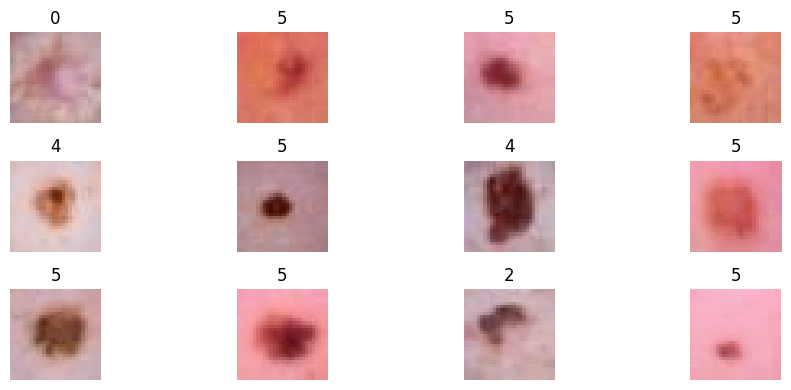

In [98]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        # Permute the dimensions from (C, H, W) to (H, W, C) for matplotlib
        img = x.permute(1, 2, 0)
        plt.imshow(img) # Removed cmap="gray" as it's an RGB image
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [99]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [100]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [101]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), # Changed from 1 to 3 input channels
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=7, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [102]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits, current_num_classes):
    if current_num_classes == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    losses = [] # <--- Nueva lista para guardar las pérdidas

    # Inferimos el número de clases
    current_num_classes = model.classifier[1].out_features if hasattr(model, 'classifier') else model.fc.out_features

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)

        # <--- NUEVO: Calculamos la pérdida si se proporciona un criterion
        if criterion is not None:
            loss = criterion(logits, y)
            losses.append(loss.item())

        probs_for_batch = logits_to_probs(logits, current_num_classes)

        if current_num_classes == 1:
            current_preds = (probs_for_batch >= 0.5).long()
            all_probs.append(probs_for_batch.cpu().numpy())
        else:
            current_preds = torch.argmax(probs_for_batch, dim=1).long()
            all_probs.append(probs_for_batch.cpu().numpy())

        all_labels.append(y.cpu().numpy())
        all_preds.append(current_preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)

    acc = accuracy_score(y_true, y_pred)

    if current_num_classes == 1:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')

    # <--- NUEVO: Promediamos la pérdida de todos los batches
    val_loss = np.mean(losses) if losses else 0.0

    return acc, auc, y_true, y_pred, y_prob, val_loss

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [103]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 20
# <--- Añadimos "val_loss" al historial
history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)

    # <--- Pasamos el 'criterion' a evaluate y desempacamos la sexta variable (val_loss)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_scratch, val_loader, criterion)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)  # <--- Guardamos la pérdida de validación
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

Epoch 01/20 | Train Loss: 1.2908 | Val Loss: 1.1241 | Val Acc: 0.6690 | Val AUC: 0.5206
Epoch 02/20 | Train Loss: 1.0858 | Val Loss: 1.0548 | Val Acc: 0.6690 | Val AUC: 0.6512
Epoch 03/20 | Train Loss: 1.0318 | Val Loss: 1.0259 | Val Acc: 0.6690 | Val AUC: 0.6717
Epoch 04/20 | Train Loss: 1.0162 | Val Loss: 1.0132 | Val Acc: 0.6690 | Val AUC: 0.6844
Epoch 05/20 | Train Loss: 1.0105 | Val Loss: 1.0100 | Val Acc: 0.6690 | Val AUC: 0.7008
Epoch 06/20 | Train Loss: 1.0021 | Val Loss: 0.9943 | Val Acc: 0.6690 | Val AUC: 0.7432
Epoch 07/20 | Train Loss: 0.9888 | Val Loss: 0.9719 | Val Acc: 0.6690 | Val AUC: 0.7796
Epoch 08/20 | Train Loss: 0.9651 | Val Loss: 0.9422 | Val Acc: 0.6730 | Val AUC: 0.8074
Epoch 09/20 | Train Loss: 0.9394 | Val Loss: 0.9197 | Val Acc: 0.6690 | Val AUC: 0.8236
Epoch 10/20 | Train Loss: 0.9261 | Val Loss: 0.9094 | Val Acc: 0.6770 | Val AUC: 0.8226
Epoch 11/20 | Train Loss: 0.9172 | Val Loss: 0.8943 | Val Acc: 0.6730 | Val AUC: 0.8332
Epoch 12/20 | Train Loss: 0.9087

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

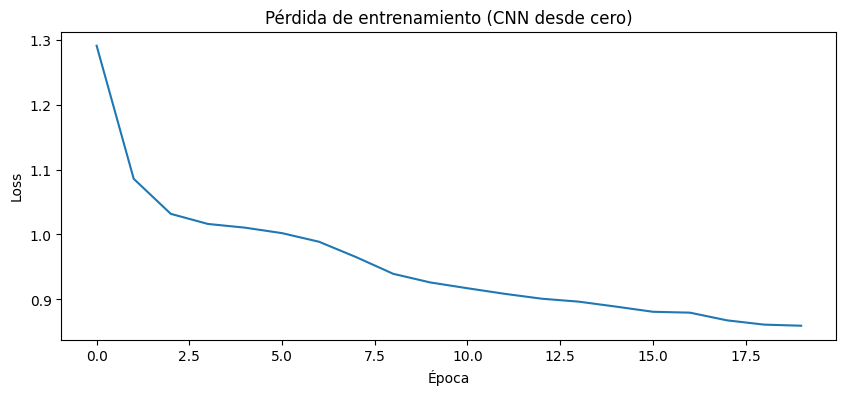

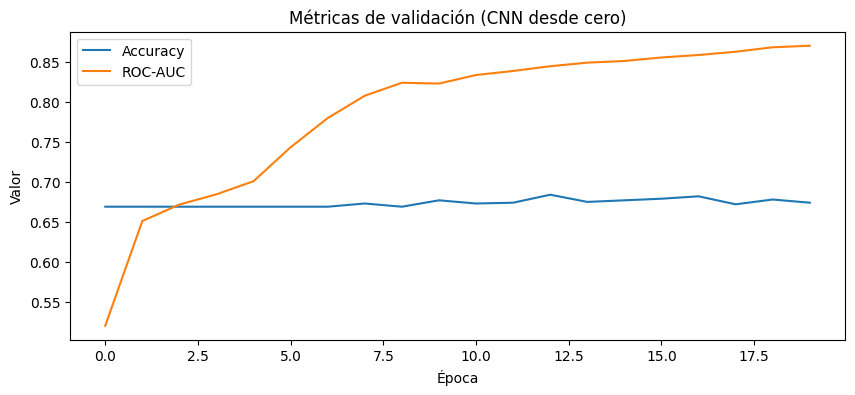

In [104]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


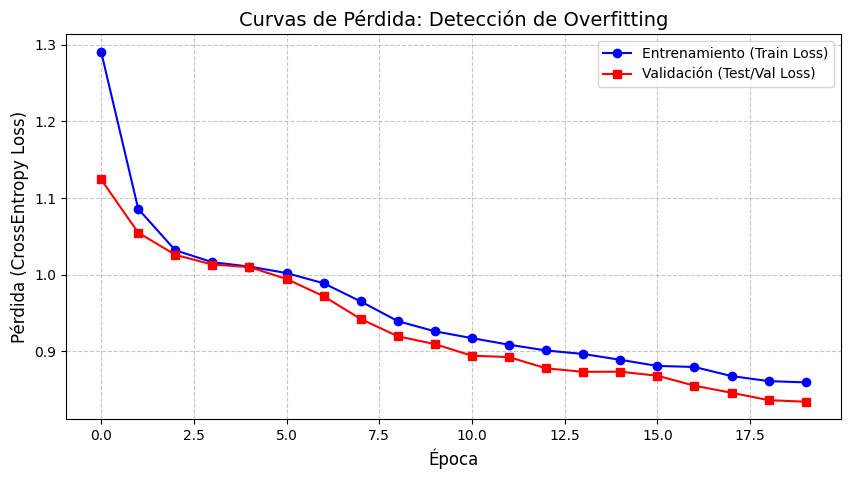

In [105]:
plt.figure(figsize=(10, 5))
# Graficamos la pérdida de entrenamiento
plt.plot(history_scratch["train_loss"], label="Entrenamiento (Train Loss)", color='blue', marker='o')
# Graficamos la pérdida de validación/test
plt.plot(history_scratch["val_loss"], label="Validación (Test/Val Loss)", color='red', marker='s')

plt.title("Curvas de Pérdida: Detección de Overfitting", fontsize=14)
plt.xlabel("Época", fontsize=12)
plt.ylabel("Pérdida (CrossEntropy Loss)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Descripcion del primer grafico 1: Mientras la línea azul demuestra que el error de entrenamiento desciende casi hasta cero, indicando que la red está memorizando perfectamente las radiografías de estudio, la línea roja revela la verdadera capacidad del modelo: la pérdida de validación baja inicialmente, pero a partir de la época 6 comienza a subir descontroladamente. Esto significa que en ese punto exacto el modelo dejó de aprender patrones médicos reales y empezó a fallar ante nuevos casos, lo que nos indica que el entrenamiento debió detenerse en la época 6 o que es estrictamente necesario usar técnicas como el Data Augmentation.


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [107]:
test_acc, test_auc, y_true, y_pred, y_prob, test_loss = evaluate(model_scratch, test_loader, criterion)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print(f"Test Loss:  {test_loss:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.6868
Test ROC-AUC:  0.8418
Test Loss:  0.8584

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        66
           1     0.2000    0.0291    0.0508       103
           2     0.4355    0.2455    0.3140       220
           3     0.0000    0.0000    0.0000        23
           4     0.0000    0.0000    0.0000       223
           5     0.7074    0.9843    0.8232      1341
           6     0.0000    0.0000    0.0000        29

    accuracy                         0.6868      2005
   macro avg     0.1918    0.1798    0.1697      2005
weighted avg     0.5312    0.6868    0.5876      2005



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[   0,    2,   13,    0,    0,   51,    0],
       [   0,    3,   13,    0,    0,   87,    0],
       [   0,    9,   54,    0,    0,  157,    0],
       [   0,    1,    1,    0,    0,   21,    0],
       [   0,    0,   19,    0,    0,  204,    0],
       [   0,    0,   21,    0,    0, 1320,    0],
       [   0,    0,    3,    0,    0,   26,    0]])

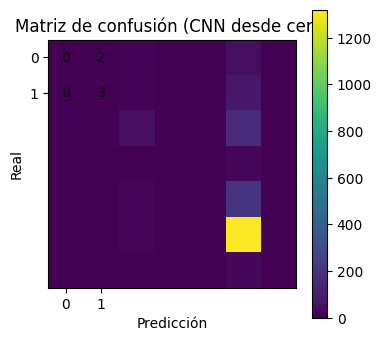

In [108]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [109]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [130]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 20
history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)


    val_acc, val_auc, _, _, _, val_loss = evaluate(model_aug, val_loader, criterion)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss) # Guardamos la pérdida
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

Epoch 01/20 | Train Loss: 1.2265 | Val Loss: 1.1008 | Val Acc: 0.6690 | Val AUC: 0.6164
Epoch 02/20 | Train Loss: 1.0588 | Val Loss: 1.0472 | Val Acc: 0.6690 | Val AUC: 0.6625
Epoch 03/20 | Train Loss: 1.0247 | Val Loss: 1.0200 | Val Acc: 0.6690 | Val AUC: 0.6838
Epoch 04/20 | Train Loss: 1.0122 | Val Loss: 1.0206 | Val Acc: 0.6690 | Val AUC: 0.7232
Epoch 05/20 | Train Loss: 0.9963 | Val Loss: 0.9848 | Val Acc: 0.6690 | Val AUC: 0.7543
Epoch 06/20 | Train Loss: 0.9834 | Val Loss: 0.9560 | Val Acc: 0.6690 | Val AUC: 0.7892
Epoch 07/20 | Train Loss: 0.9564 | Val Loss: 0.9535 | Val Acc: 0.6690 | Val AUC: 0.8134
Epoch 08/20 | Train Loss: 0.9404 | Val Loss: 0.9202 | Val Acc: 0.6680 | Val AUC: 0.8221
Epoch 09/20 | Train Loss: 0.9402 | Val Loss: 0.9449 | Val Acc: 0.6690 | Val AUC: 0.8232
Epoch 10/20 | Train Loss: 0.9250 | Val Loss: 0.9057 | Val Acc: 0.6690 | Val AUC: 0.8348
Epoch 11/20 | Train Loss: 0.9118 | Val Loss: 0.9086 | Val Acc: 0.6700 | Val AUC: 0.8345
Epoch 12/20 | Train Loss: 0.9072

### 6.1. Comparación rápida


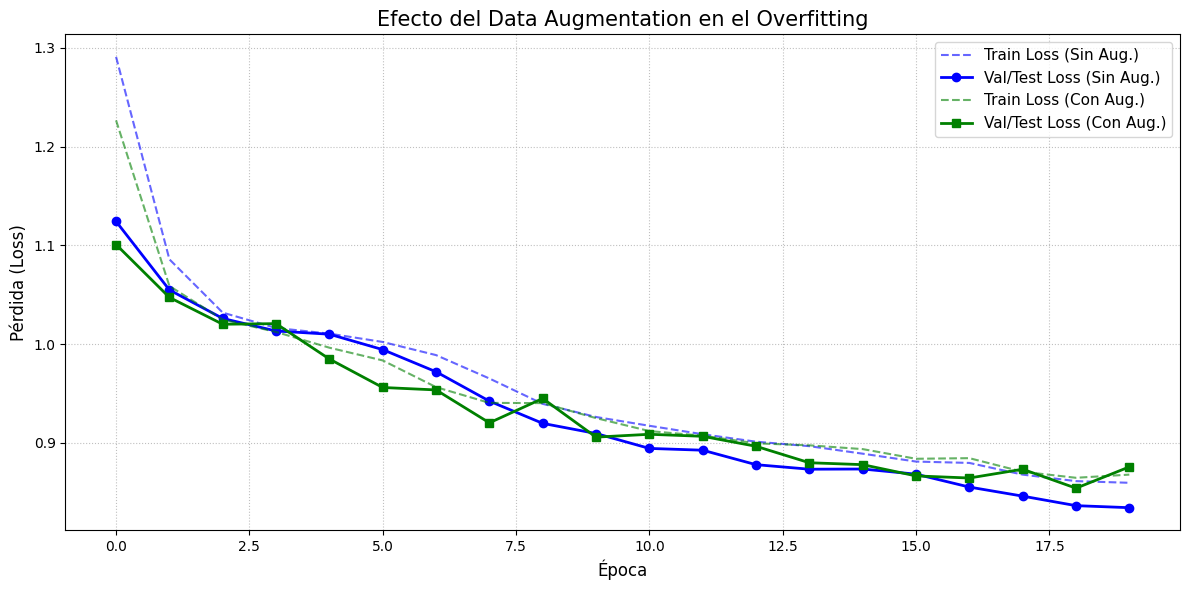

In [131]:
plt.figure(figsize=(12, 6))

plt.plot(history_scratch["train_loss"], label="Train Loss (Sin Aug.)", color='blue', linestyle='--', alpha=0.6)
plt.plot(history_scratch["val_loss"], label="Val/Test Loss (Sin Aug.)", color='blue', marker='o', linewidth=2)

plt.plot(history_aug["train_loss"], label="Train Loss (Con Aug.)", color='green', linestyle='--', alpha=0.6)
plt.plot(history_aug["val_loss"], label="Val/Test Loss (Con Aug.)", color='green', marker='s', linewidth=2)

plt.title("Efecto del Data Augmentation en el Overfitting", fontsize=15)
plt.xlabel("Época", fontsize=12)
plt.ylabel("Pérdida (Loss)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.8)
plt.tight_layout()
plt.show()

descripcion del grafico 2: El modelo azul está "haciendo trampa" en el examen memorizando las respuestas, por lo que reprueba cuando le cambias las preguntas. El modelo verde, aunque le cuesta más trabajo estudiar (su Train Loss no baja a cero), realmente está aprendiendo a resolver el problema, y por eso le va mejor en el examen final (su Val Loss se mantiene bajo y estable).

In [114]:
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(model_aug, test_loader, criterion)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")

Sin augmentation  | test_acc=0.6868 | test_auc=0.8418
Con augmentation  | test_acc=0.6698 | test_auc=0.8005


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [115]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
    # Removed T.Lambda(lambda x: x.repeat(3, 1, 1)) as dermamnist is already 3-channel
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
    # Removed T.Lambda(lambda x: x.repeat(3, 1, 1)) as dermamnist is already 3-channel
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [116]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [119]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": [], "val_loss": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)
    history_tl_stage1["val_loss"].append(val_loss)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage1 Epoch 01 | train_loss=0.8141 | val_acc=0.7228 | val_auc=0.9046
Stage1 Epoch 02 | train_loss=0.7868 | val_acc=0.7268 | val_auc=0.9090
Stage1 Epoch 03 | train_loss=0.7667 | val_acc=0.7099 | val_auc=0.9147
Stage1 Epoch 04 | train_loss=0.7558 | val_acc=0.7258 | val_auc=0.9151


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [120]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [122]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": [], "val_loss": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)
    history_tl_stage2["val_loss"].append(val_loss)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage2 Epoch 01 | train_loss=0.5863 | val_loss=0.6559 | val_acc=0.7468 | val_auc=0.9337
Stage2 Epoch 02 | train_loss=0.4965 | val_loss=0.6945 | val_acc=0.7567 | val_auc=0.9300
Stage2 Epoch 03 | train_loss=0.4159 | val_loss=0.7376 | val_acc=0.7318 | val_auc=0.9206
Stage2 Epoch 04 | train_loss=0.3489 | val_loss=0.7329 | val_acc=0.7567 | val_auc=0.9310


In [124]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 20
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": [], "val_loss": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)
    history_tl_stage2["val_loss"].append(val_loss)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage2 Epoch 01 | train_loss=0.2665 | val_loss=0.8459 | val_acc=0.7318 | val_auc=0.9194
Stage2 Epoch 02 | train_loss=0.1973 | val_loss=0.8251 | val_acc=0.7577 | val_auc=0.9349
Stage2 Epoch 03 | train_loss=0.1558 | val_loss=0.9137 | val_acc=0.7517 | val_auc=0.9240
Stage2 Epoch 04 | train_loss=0.1212 | val_loss=1.0034 | val_acc=0.7368 | val_auc=0.9180
Stage2 Epoch 05 | train_loss=0.1061 | val_loss=0.9981 | val_acc=0.7647 | val_auc=0.9248
Stage2 Epoch 06 | train_loss=0.0840 | val_loss=1.1007 | val_acc=0.7318 | val_auc=0.9142
Stage2 Epoch 07 | train_loss=0.0695 | val_loss=1.1270 | val_acc=0.7438 | val_auc=0.9152
Stage2 Epoch 08 | train_loss=0.0635 | val_loss=1.1975 | val_acc=0.7418 | val_auc=0.9209
Stage2 Epoch 09 | train_loss=0.0580 | val_loss=1.1908 | val_acc=0.7627 | val_auc=0.9242
Stage2 Epoch 10 | train_loss=0.0512 | val_loss=1.2304 | val_acc=0.7607 | val_auc=0.9272
Stage2 Epoch 11 | train_loss=0.0475 | val_loss=1.2051 | val_acc=0.7418 | val_auc=0.9243
Stage2 Epoch 12 | train_loss=0.0

### 7.3. Evaluación en test del modelo con transfer learning


In [125]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl, test_loss_tl = evaluate(resnet, test_loader_tl, criterion)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f} | test_loss={test_loss_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl

Transfer learning | test_acc=0.7561 | test_auc=0.9181 | test_loss=1.3323

              precision    recall  f1-score   support

           0     0.3846    0.4545    0.4167        66
           1     0.4375    0.6796    0.5323       103
           2     0.5380    0.4500    0.4901       220
           3     0.4800    0.5217    0.5000        23
           4     0.5103    0.3318    0.4022       223
           5     0.8710    0.9060    0.8882      1341
           6     0.8889    0.5517    0.6809        29

    accuracy                         0.7561      2005
   macro avg     0.5872    0.5565    0.5586      2005
weighted avg     0.7518    0.7561    0.7492      2005



array([[  30,   20,    4,    0,    6,    6,    0],
       [  15,   70,    5,    3,    2,    8,    0],
       [  16,   21,   99,    3,   22,   59,    0],
       [   1,    4,    1,   12,    0,    5,    0],
       [   6,   11,   31,    3,   74,   97,    1],
       [  10,   29,   42,    4,   40, 1215,    1],
       [   0,    5,    2,    0,    1,    5,   16]])

### 7.4. Comparación global (resumen)


In [126]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.6868 | auc=0.8418
CNN desde cero (con aug)  | acc=0.6698 | auc=0.8005
Transfer learning (ResNet) | acc=0.7561 | auc=0.9181


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [127]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


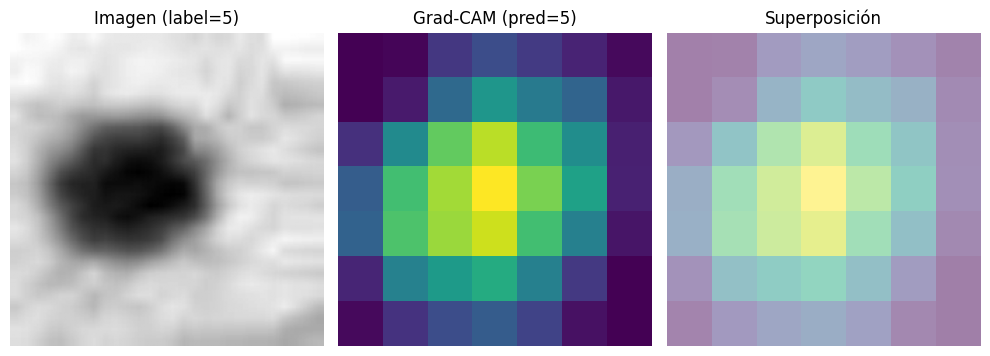

In [128]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [129]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.
